In [51]:
# STEP 1: Import libraries
#CraveConnect Case Study by Shikhar Panthari, Abhinav Singh, Ankit Nandi
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Libraries successfully loaded.")

Libraries successfully loaded.


In [52]:
#Loading the dataset


df = pd.read_csv("food_app_customer_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 18)


,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Membership_upgrade,Avg_Order_Value,Preferred_Cuisine,Weekend_Order_Ratio,App_Rating,Avg_Delivery_Tips,Discount_Usage_Freq,Total_Cuisines_Tried,Avg_Delivery_Time,Last_Month_Complaints
0,CUST1000,Connor Rowland,40,Female,52777,27,Gold,5.2,0.0,46.16,Indian,0.55,3,5.37,High,8,32.4,0
1,CUST1001,Cameron Miles MD,28,Female,65910,84,Basic,12.2,0.0,95.62,Healthy,0.60,4,8.33,Medium,6,41.1,1
2,CUST1002,Dennis Price,63,Male,56731,51,Silver,2.9,1.0,69.89,Chinese,0.44,4,8.01,Low,5,47.3,0
3,CUST1003,Jessica Jones,23,Female,40559,56,Platinum,11.1,0.0,44.56,Healthy,0.55,5,3.82,Low,9,32.2,0
4,CUST1004,Kevin Bauer,38,Male,79675,74,Basic,10.7,0.0,52.27,Indian,0.28,3,6.14,Medium,2,37.7,0


In [53]:
#Remove rows with missing upgrade labels

df_model = df.dropna(subset=["Membership_upgrade"]).copy()

print("Rows used for modeling:", df_model.shape)

Rows used for modeling: (1800, 18)


In [54]:
df["Membership_upgrade"].value_counts()
df["Membership_upgrade"].value_counts(normalize=True)

Membership_upgrade
0.0    0.741667
1.0    0.258333
Name: proportion, dtype: float64

In [55]:
df.groupby("Membership_Level")[[
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Avg_Order_Value",
    "Spending_Score",
    "Total_Cuisines_Tried"
]].mean()

,Age,Annual_Income,Purchase_Frequency,Avg_Order_Value,Spending_Score,Total_Cuisines_Tried
Membership_Level,,,,,,
Basic,43.738908,60337.556314,7.943345,59.391246,51.098976,5.353242
Gold,43.474480,59110.209830,8.159357,60.698469,50.383743,5.449905
Platinum,43.565068,60687.835616,8.222945,60.026267,50.304795,5.380137
Silver,43.495784,59613.920742,7.805565,59.295211,50.005059,5.382799


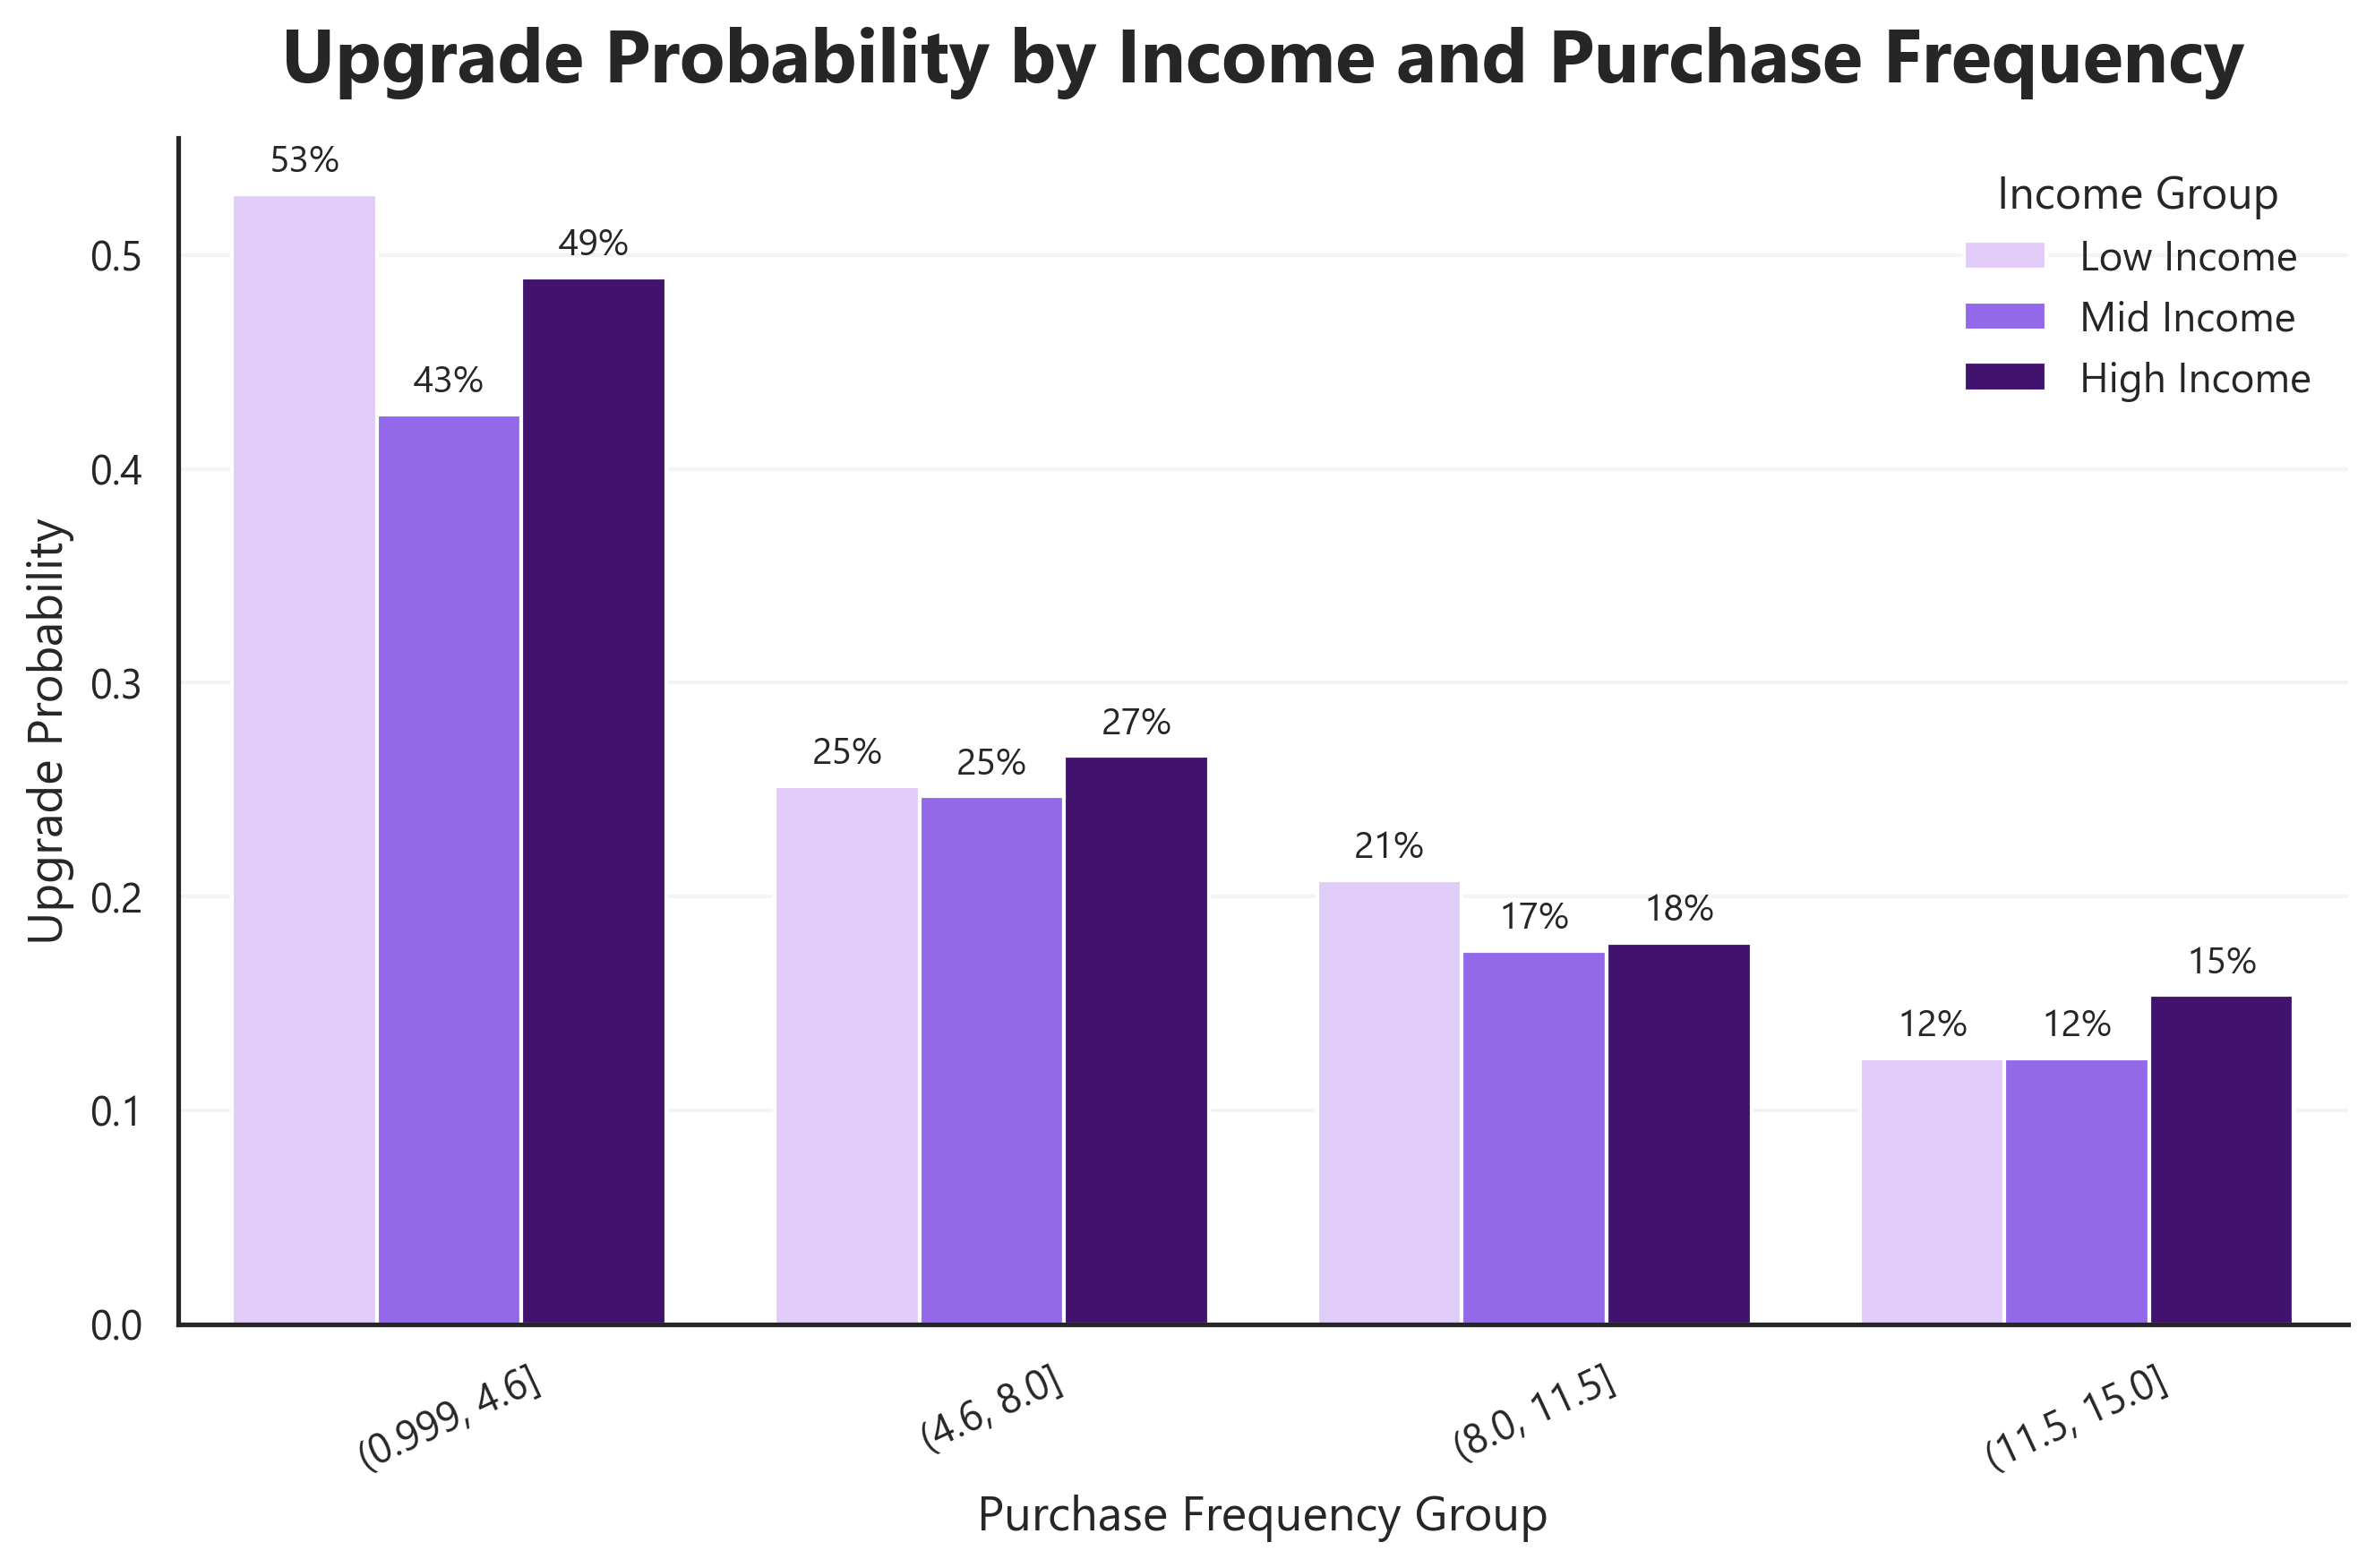

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="white")

plt.rcParams.update({
    "font.family": "Segoe UI",
    "axes.titlesize": 20,
    "axes.labelsize": 13,
    "axes.titleweight": "bold"
})

# Create bins
df["income_group"] = pd.qcut(
    df["Annual_Income"],
    3,
    labels=["Low Income","Mid Income","High Income"]
)

df["freq_group"] = pd.qcut(
    df["Purchase_Frequency"],
    4
)

palette = {
    "Low Income": "#e1c3ff",
    "Mid Income": "#8c52ff",
    "High Income": "#41047e"
}

fig, ax = plt.subplots(figsize=(9,6), dpi=300)

sns.barplot(
    data=df,
    x="freq_group",
    y="Membership_upgrade",
    hue="income_group",
    palette=palette,
    errorbar=None,  # remove confidence intervals
    ax=ax
)

# Add percentage labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height*100:.0f}%",
            (p.get_x() + p.get_width()/2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0,4),
            textcoords="offset points"
        )

ax.set_ylabel("Upgrade Probability")
ax.set_xlabel("Purchase Frequency Group")
ax.set_title("Upgrade Probability by Income and Purchase Frequency", pad=15)

sns.despine()
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25)

plt.legend(title="Income Group", frameon=False)

plt.tight_layout()
plt.show()

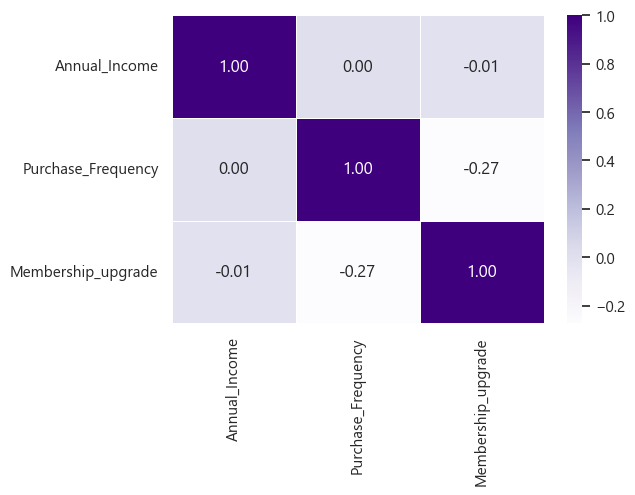

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# select only relevant columns
corr_data = df[["Annual_Income", "Purchase_Frequency", "Membership_upgrade"]]

# compute correlation
corr_matrix = corr_data.corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5
)

plt.show()

In [58]:
service_metrics = df.groupby("Membership_upgrade")[[
    "Avg_Delivery_Time",
    "Last_Month_Complaints",
    "App_Rating",
    "Avg_Delivery_Tips"
]].mean()

service_metrics

,Avg_Delivery_Time,Last_Month_Complaints,App_Rating,Avg_Delivery_Tips
Membership_upgrade,,,,
0.0,34.874607,0.148315,3.700375,5.997191
1.0,35.367527,0.163441,3.666667,6.026516


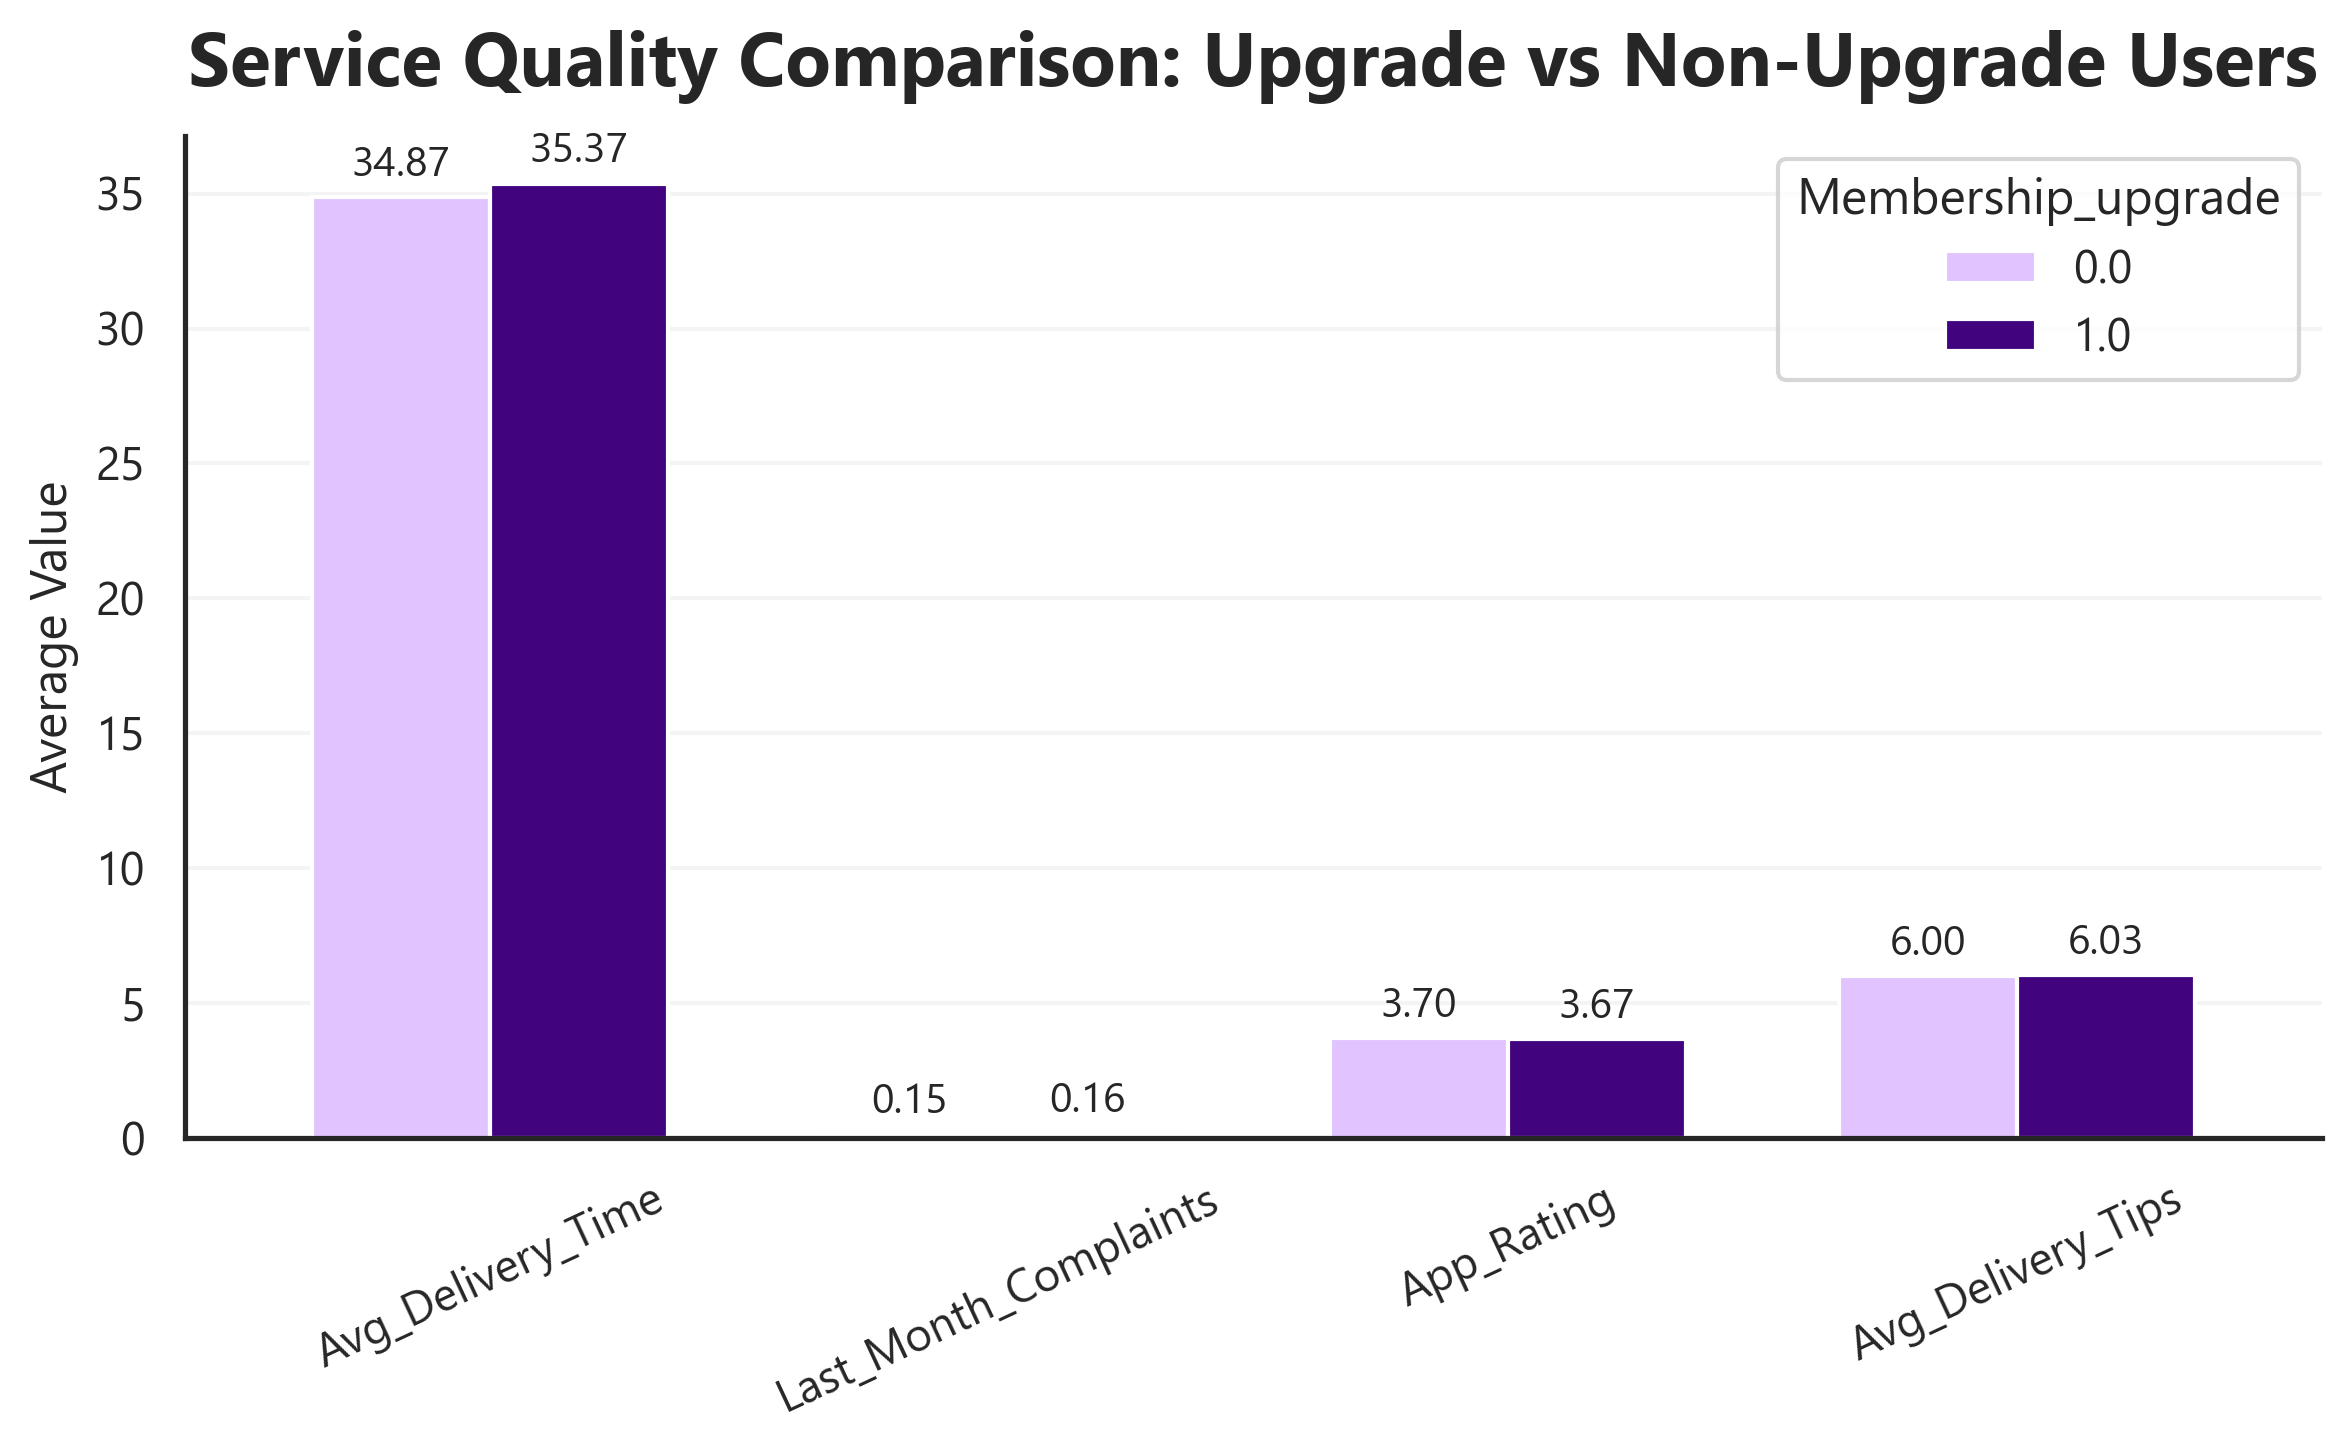

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

plt.rcParams.update({
    "font.family": "Segoe UI",
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "axes.titleweight": "bold"
})

fig, ax = plt.subplots(figsize=(8,5), dpi=300)

service_metrics.T.plot(
    kind="bar",
    color=["#e1c3ff", "#41047e"],  # No Upgrade, Upgrade
    width=0.7,
    ax=ax
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)

ax.set_ylabel("Average Value")
ax.set_xlabel("")
ax.set_title("Service Quality Comparison: Upgrade vs Non-Upgrade Users", pad=12)

sns.despine()
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [60]:
# FEATURE ENGINEERING
# Creating behavioral indicators for customer analysis
print("Creating engineered behavioral features...\n")

#  Spend Efficiency
# Spending relative to how often the customer orders

df_model["Spend_Efficiency"] = (
    df_model["Spending_Score"] /
    (df_model["Purchase_Frequency"] + 1)
)

print("Spend_Efficiency created.")


# Complaint Rate
# Complaints normalized by customer usage

df_model["Complaint_Rate"] = (
    df_model["Last_Month_Complaints"] /
    (df_model["Purchase_Frequency"] + 1)
)

print("Complaint_Rate created.")


# Cuisine Diversity
# Measures how many cuisines the user explores

df_model["Cuisine_Diversity"] = (
    df_model["Total_Cuisines_Tried"] / 8
)

print("Cuisine_Diversity created.")

#  Delivery Pain Index
# Combined indicator of delivery delays and complaints

df_model["Delivery_Pain_Index"] = (
    (df_model["Avg_Delivery_Time"] / 60)
    + df_model["Last_Month_Complaints"]
)

print("Delivery_Pain_Index created.")


# Tip-to-Order Ratio
# Tipping behavior relative to order value

df_model["Tip_to_Order_Ratio"] = (
    df_model["Avg_Delivery_Tips"] /
    (df_model["Avg_Order_Value"] + 1)
)

print("Tip_to_Order_Ratio created.")


print("\nFeature engineering completed successfully.")
print("\nNew columns added:")

new_features = [
    "Spend_Efficiency",
    "Complaint_Rate",
    "Cuisine_Diversity",
    "Delivery_Pain_Index",
    "Tip_to_Order_Ratio"
]

print(new_features)

Creating engineered behavioral features...

Spend_Efficiency created.
Complaint_Rate created.
Cuisine_Diversity created.
Delivery_Pain_Index created.
Tip_to_Order_Ratio created.

Feature engineering completed successfully.

New columns added:
['Spend_Efficiency', 'Complaint_Rate', 'Cuisine_Diversity', 'Delivery_Pain_Index', 'Tip_to_Order_Ratio']


In [61]:
#Define target and input features

print("Step 5: Creating feature matrix and target variable.\n")

y = df_model["Membership_upgrade"]

X = df_model.drop([
    "Membership_upgrade",
    "CustomerID",
    "Name",
    "Membership_Level"
], axis=1)

print("Number of features:", X.shape[1])

Step 5: Creating feature matrix and target variable.

Number of features: 19


In [62]:
# Split data into training and testing sets


print("Step 6: Splitting the dataset into training and testing sets.\n")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Step 6: Splitting the dataset into training and testing sets.

Training samples: (1440, 19)
Testing samples: (360, 19)


In [63]:
#Data preprocessing pipeline


print("Step 7: Preparing preprocessing pipeline.\n")

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

print("Preprocessing pipeline created.")

Step 7: Preparing preprocessing pipeline.

Preprocessing pipeline created.


In [64]:
#Logistic Regression baseline

print("Training Logistic Regression model.\n")

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

log_model.fit(X_train, y_train)

Training Logistic Regression model.



,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
# Random Forest model


print("Training Random Forest model.\n")

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

Training Random Forest model.



,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
#Model Evaluation

print("Evaluating model performance.\n")

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("PR-AUC:", average_precision_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Evaluating model performance.

ROC-AUC: 0.7100398695179413
PR-AUC: 0.6026418740900154

Confusion Matrix:
[[263   4]
 [ 62  31]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.99      0.89       267
         1.0       0.89      0.33      0.48        93

    accuracy                           0.82       360
   macro avg       0.85      0.66      0.69       360
weighted avg       0.83      0.82      0.78       360



Running SHAP analysis to identify drivers of upgrade.



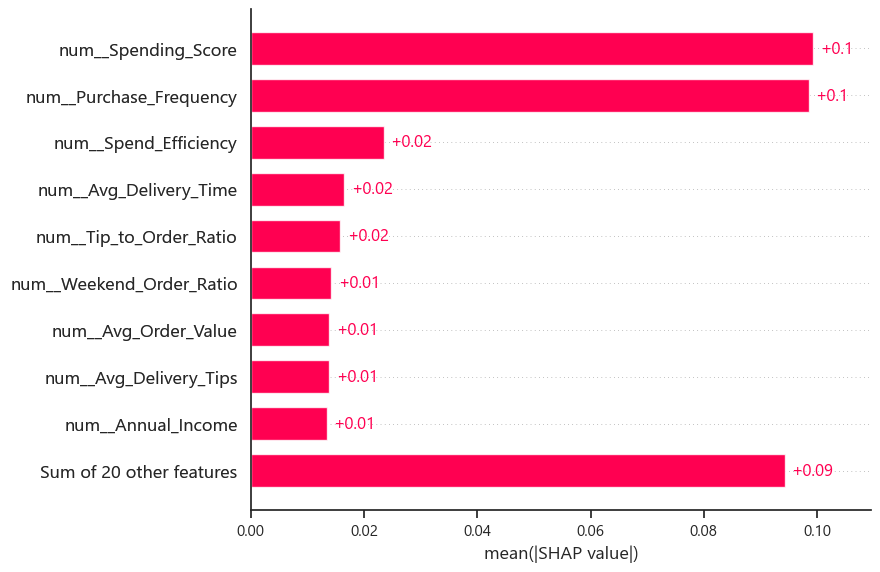

In [67]:
# Model Interpretation using SHAP

import shap
import pandas as pd

print("Running SHAP analysis to identify drivers of upgrade.\n")

# Extract trained Random Forest model
rf = rf_model.named_steps["model"]

# Transform test data
X_test_transformed = rf_model.named_steps["preprocessor"].transform(X_test)

# Get feature names
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Convert to DataFrame
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# SHAP explainer
explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values = explainer(X_test_transformed)

# Extract class 1 (Upgrade = Yes)
shap_values_class1 = shap_values.values[:,:,1]

# Plot top drivers
shap.plots.bar(shap.Explanation(
    values=shap_values_class1,
    base_values=shap_values.base_values[:,1],
    data=X_test_transformed,
    feature_names=feature_names
), max_display=10)

In [68]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Logistic Regression predictions
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

# Random Forest predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

# Create validation table
validation_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    
    "PR-AUC": [
        average_precision_score(y_test, log_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

# Round values for better readability
validation_table = validation_table.round(3)

print("Model Validation Results:\n")
display(validation_table)

Model Validation Results:



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.650,0.388,0.613,0.475,0.703,0.573
1,Random Forest,0.817,0.886,0.333,0.484,0.710,0.603


In [119]:
# Predict upgrade probability
df_model["Upgrade_Probability"] = rf_model.predict_proba(X)[:,1]

# Identify high-probability upgrade users
high_upgrade_users = df_model[df_model["Upgrade_Probability"] > 0.7]


print("Number of high potential upgrade users:", len(high_upgrade_users))
high_upgrade_users = df_model[df_model["Upgrade_Probability"] > 0.1]

high_upgrade_users.sort_values(by= "Upgrade_Probability")


Number of high potential upgrade users: 314


,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Membership_upgrade,Avg_Order_Value,...,Discount_Usage_Freq,Total_Cuisines_Tried,Avg_Delivery_Time,Last_Month_Complaints,Spend_Efficiency,Complaint_Rate,Cuisine_Diversity,Delivery_Pain_Index,Tip_to_Order_Ratio,Upgrade_Probability
998,CUST1998,Abigail Hendricks,38,Female,51739,59,Gold,5.2,0.0,75.03,...,Medium,2,31.3,0,9.516129,0.0,0.250,0.521667,0.054978,0.103333
1829,CUST2829,Anthony Brown,69,Female,63557,52,Basic,3.7,0.0,50.39,...,Low,10,22.6,0,11.063830,0.0,1.250,0.376667,0.124732,0.103333
1747,CUST2747,Timothy Hubbard,39,Male,70248,82,Platinum,13.2,0.0,53.38,...,Low,2,18.0,0,5.774648,0.0,0.250,0.300000,0.139941,0.103333
1285,CUST2285,Amanda Mclaughlin,49,Male,58287,47,Silver,1.4,0.0,59.32,...,Medium,4,33.7,0,19.583333,0.0,0.500,0.561667,0.073773,0.103333
556,CUST1556,Jennifer Calderon,55,Female,86812,44,Silver,5.0,0.0,55.04,...,Medium,1,46.5,0,7.333333,0.0,0.125,0.775000,0.067273,0.103333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,CUST2304,James Davis,21,Female,60996,17,Platinum,1.8,1.0,73.75,...,Low,3,43.2,0,6.071429,0.0,0.375,0.720000,0.141538,0.956667
1776,CUST2776,Michael Hunt,21,Female,74981,9,Silver,3.6,1.0,89.09,...,Low,5,22.1,0,1.956522,0.0,0.625,0.368333,0.116661,0.956667
1683,CUST2683,Sherry Long,49,Female,58260,20,Silver,3.7,1.0,77.05,...,Low,7,29.9,0,4.255319,0.0,0.875,0.498333,0.093914,0.960000
1403,CUST2403,Steven Ward,26,Female,61153,14,Gold,2.2,1.0,75.61,...,High,6,40.3,0,4.375000,0.0,0.750,0.671667,0.133011,0.963333


In [123]:
row = X.iloc[[898]]   # the customer row you are testing
print(rf_model.predict_proba(row))
print(row)

[[0.89666667 0.10333333]]
     Age  Gender  Annual_Income  Spending_Score  Purchase_Frequency  \
998   38  Female          51739              59                 5.2   

     Avg_Order_Value Preferred_Cuisine  Weekend_Order_Ratio  App_Rating  \
998            75.03           Mexican                 0.26           5   

     Avg_Delivery_Tips Discount_Usage_Freq  Total_Cuisines_Tried  \
998               4.18              Medium                     2   

     Avg_Delivery_Time  Last_Month_Complaints  Spend_Efficiency  \
998               31.3                      0          9.516129   

     Complaint_Rate  Cuisine_Diversity  Delivery_Pain_Index  \
998             0.0               0.25             0.521667   

     Tip_to_Order_Ratio  
998            0.054978  


In [70]:
persona_profile = high_upgrade_users[[
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Avg_Order_Value",
    "Spending_Score",
    "Total_Cuisines_Tried",
    "Weekend_Order_Ratio"
]].mean()

print(persona_profile)

Age                        43.477707
Annual_Income           59371.761146
Purchase_Frequency          5.595860
Avg_Order_Value            60.030350
Spending_Score             31.958599
Total_Cuisines_Tried        5.245223
Weekend_Order_Ratio         0.507070
dtype: float64


In [71]:
high_value_low_rating = df_model[
    (df_model["Spending_Score"] > 70) &
    (df_model["App_Rating"] < 3)
]

In [72]:
#Identify High Value but Low Rating Users

high_value_low_rating = df_model[
    (df_model["Spending_Score"] > 70) &
    (df_model["App_Rating"] < 3)
]

print("Number of High-Value / Low-Rating users:", len(high_value_low_rating))

Number of High-Value / Low-Rating users: 95


In [73]:
percentage = len(high_value_low_rating) / len(df_model) * 100

print("Percentage of total users:", round(percentage,2), "%")

Percentage of total users: 5.28 %


In [74]:
revenue_stats = high_value_low_rating[[
    "Purchase_Frequency",
    "Avg_Order_Value",
    "Spend_Efficiency"
]].mean()

revenue_stats["Estimated_Monthly_Spend"] = (
    revenue_stats["Purchase_Frequency"] *
    revenue_stats["Avg_Order_Value"]
)

print(revenue_stats)

Purchase_Frequency           8.437895
Avg_Order_Value             59.676105
Spend_Efficiency            11.651285
Estimated_Monthly_Spend    503.540695
dtype: float64


In [75]:
normal_users = df_model[
    ~((df_model["Spending_Score"] > 70) &
      (df_model["App_Rating"] < 3))
]

comparison = pd.DataFrame({
    "Metric":[
        "Purchase_Frequency",
        "Spending_Score",
        "Spend_Efficiency",
        "Avg_Order_Value"
    ],
    "High_Value_Low_Rating":[
        high_value_low_rating["Purchase_Frequency"].mean(),
        high_value_low_rating["Spending_Score"].mean(),
        high_value_low_rating["Spend_Efficiency"].mean(),
        high_value_low_rating["Avg_Order_Value"].mean()

        
            
    ],
    "Other_Customers":[
        normal_users["Purchase_Frequency"].mean(),
        normal_users["Spending_Score"].mean(),
        normal_users["Spend_Efficiency"].mean(),
        normal_users["Avg_Order_Value"].mean(),

    ]
})

comparison

,Metric,High_Value_Low_Rating,Other_Customers
0,Purchase_Frequency,8.437895,8.200821
1,Spending_Score,85.263158,49.857478
2,Spend_Efficiency,11.651285,7.138673
3,Avg_Order_Value,59.676105,60.104933


In [76]:
rf = rf_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get importance values
importances = rf.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                     Feature  Importance
3    num__Purchase_Frequency    0.138428
2        num__Spending_Score    0.135531
11     num__Spend_Efficiency    0.086103
15   num__Tip_to_Order_Ratio    0.062155
1         num__Annual_Income    0.058190
7     num__Avg_Delivery_Tips    0.057157
4       num__Avg_Order_Value    0.055998
9     num__Avg_Delivery_Time    0.055855
5   num__Weekend_Order_Ratio    0.055158
14  num__Delivery_Pain_Index    0.052298


In [77]:
importance_df["Feature"] = importance_df["Feature"].str.replace("num__", "")
importance_df["Feature"] = importance_df["Feature"].str.replace("cat__", "")

C:\Users\SHIKHAR\AppData\Local\Temp\ipykernel_19380\792957646.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


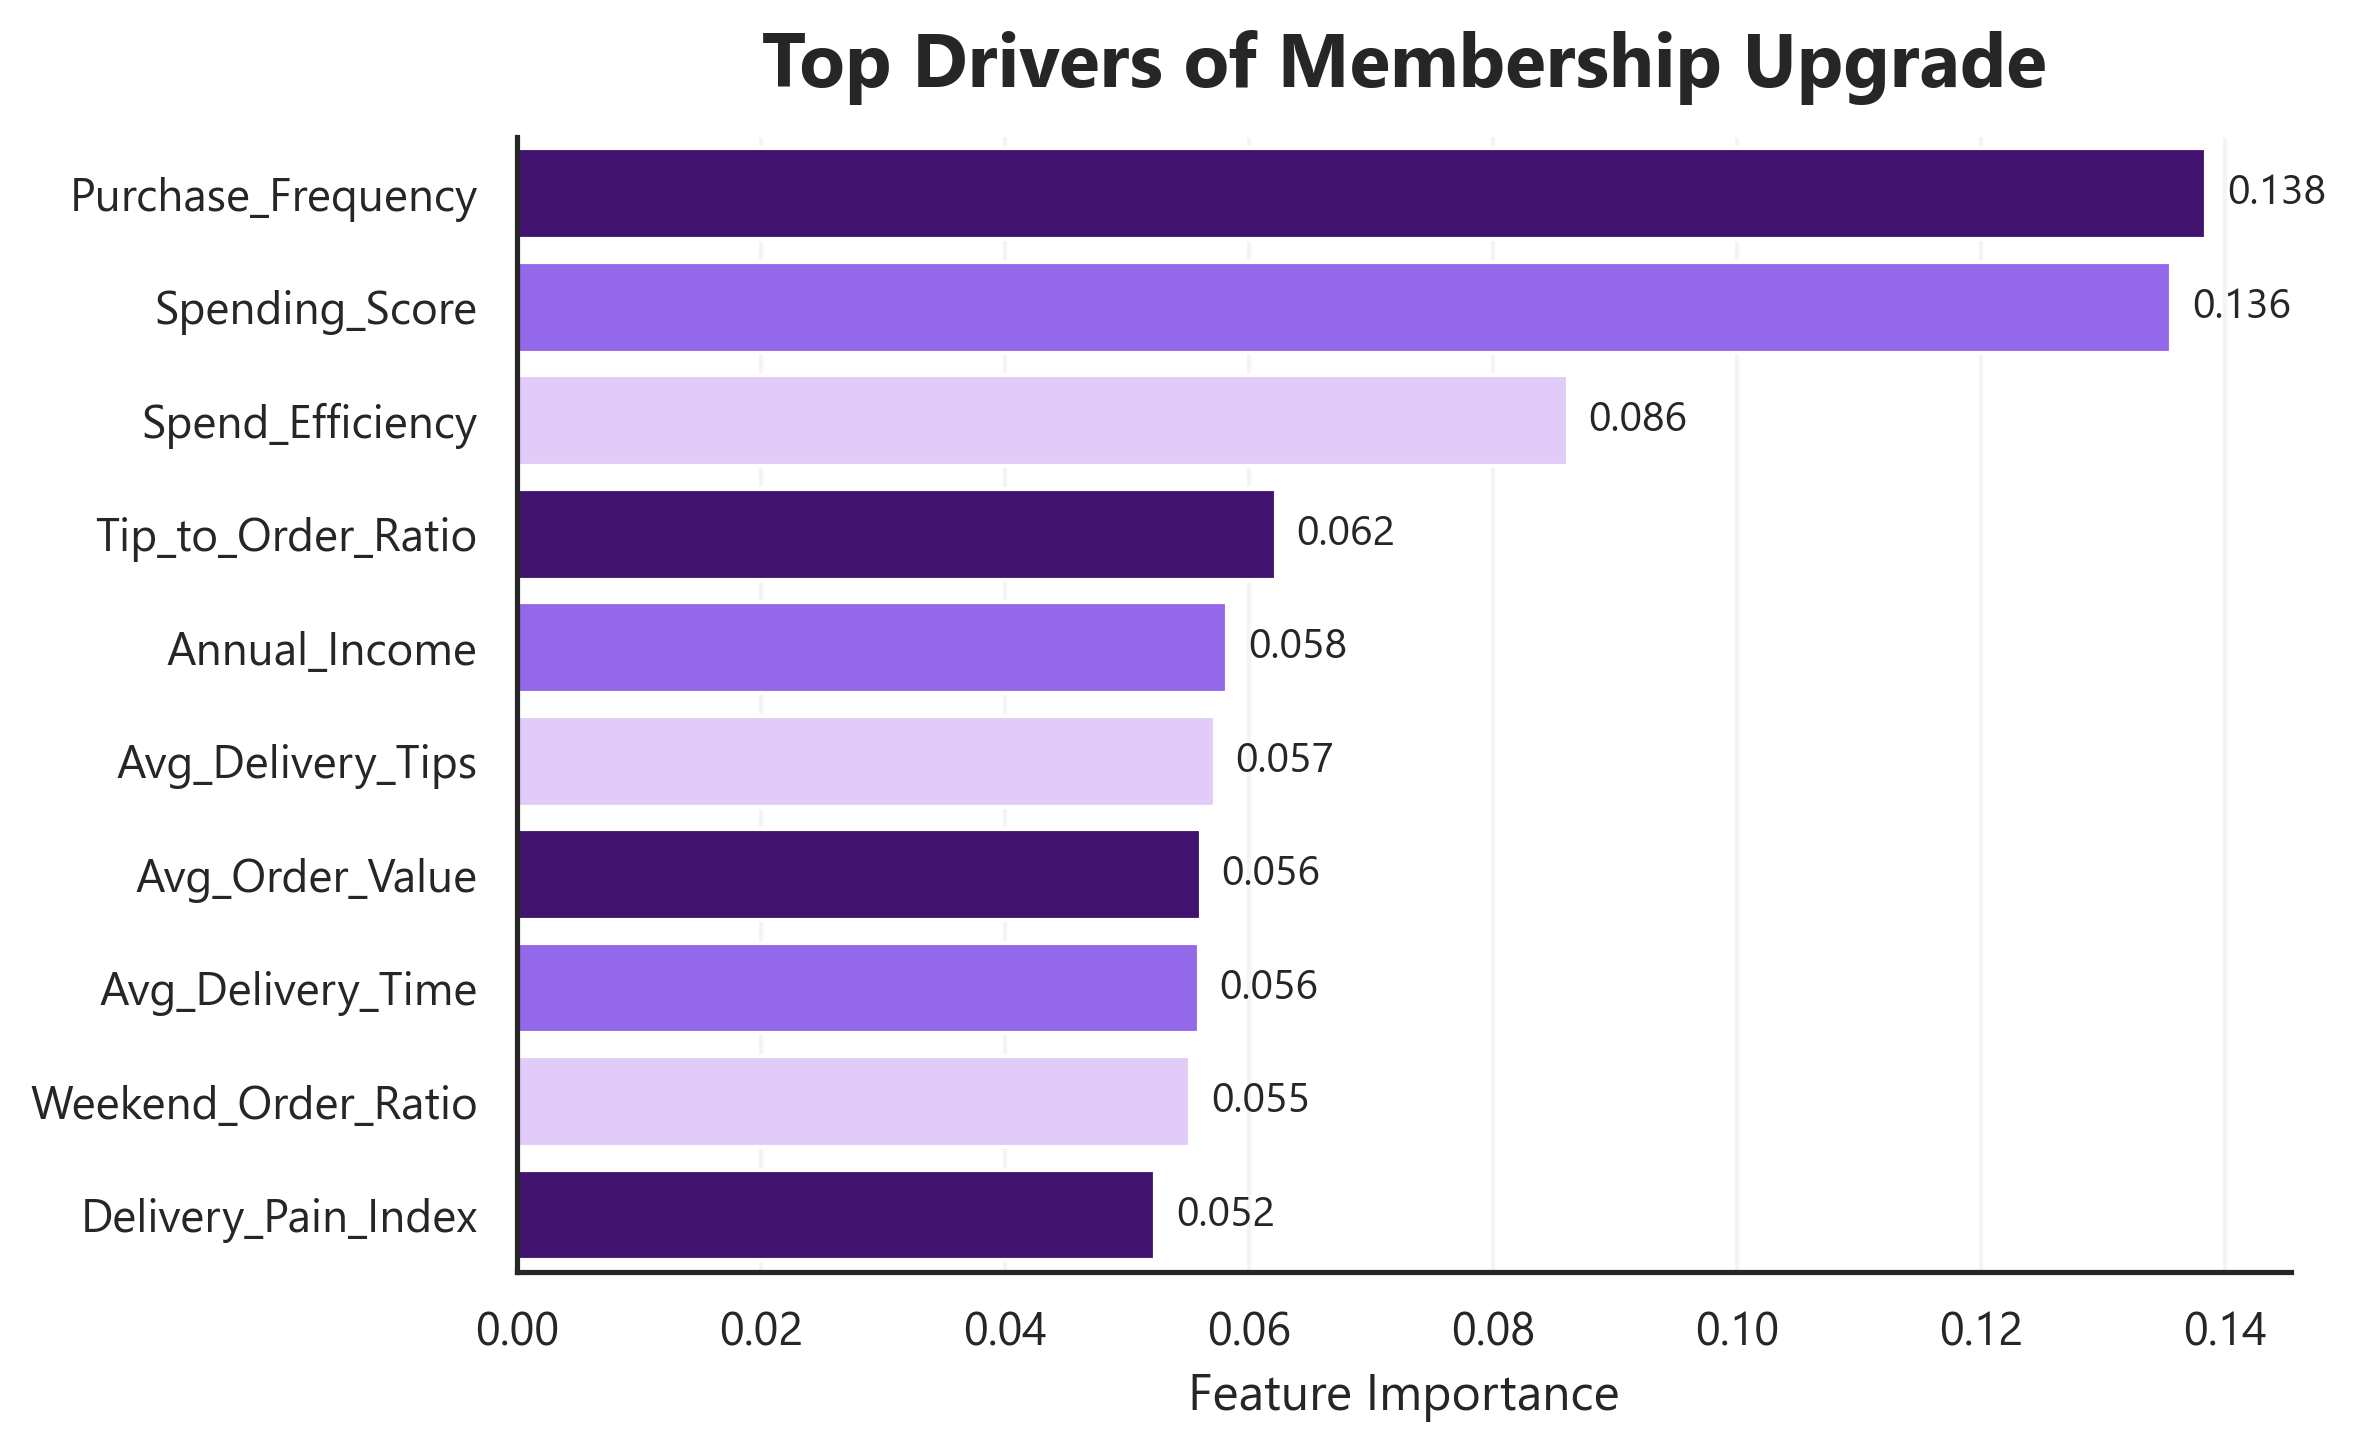

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.rcParams.update({
    "font.family": "Segoe UI",
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "axes.titleweight": "bold"
})

# Sort to show strongest feature at top
top_features = importance_df.head(10).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8,5), dpi=300)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette=sns.color_palette(["#41047e", "#8c52ff", "#e1c3ff"], n_colors=10),
    ax=ax
)

# Add value labels
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height()/2),
        ha="left",
        va="center",
        fontsize=10,
        xytext=(5,0),
        textcoords="offset points"
    )

ax.set_title("Top Drivers of Membership Upgrade", pad=12)
ax.set_xlabel("Feature Importance")
ax.set_ylabel("")

sns.despine()
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

In [79]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [80]:
print(X_train.columns)

Index(['Age', 'Gender', 'Annual_Income', 'Spending_Score',
       'Purchase_Frequency', 'Avg_Order_Value', 'Preferred_Cuisine',
       'Weekend_Order_Ratio', 'App_Rating', 'Avg_Delivery_Tips',
       'Discount_Usage_Freq', 'Total_Cuisines_Tried', 'Avg_Delivery_Time',
       'Last_Month_Complaints', 'Spend_Efficiency', 'Complaint_Rate',
       'Cuisine_Diversity', 'Delivery_Pain_Index', 'Tip_to_Order_Ratio'],
      dtype='object')


In [81]:
rf = rf_model.named_steps['model']

preprocessor = rf_model.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(rf.feature_importances_, index=feature_names)

importance.sort_values(ascending=False)

num__Purchase_Frequency            0.138428
num__Spending_Score                0.135531
num__Spend_Efficiency              0.086103
num__Tip_to_Order_Ratio            0.062155
num__Annual_Income                 0.058190
num__Avg_Delivery_Tips             0.057157
num__Avg_Order_Value               0.055998
num__Avg_Delivery_Time             0.055855
num__Weekend_Order_Ratio           0.055158
num__Delivery_Pain_Index           0.052298
num__Age                           0.051306
num__Total_Cuisines_Tried          0.029782
num__Cuisine_Diversity             0.029505
num__App_Rating                    0.023005
num__Complaint_Rate                0.016275
cat__Preferred_Cuisine_Indian      0.008143
cat__Discount_Usage_Freq_Medium    0.007957
cat__Discount_Usage_Freq_Low       0.007853
cat__Gender_Female                 0.007822
cat__Gender_Male                   0.007491
cat__Preferred_Cuisine_Mexican     0.006881
cat__Discount_Usage_Freq_High      0.006656
cat__Preferred_Cuisine_Italian  

In [82]:
import joblib

joblib.dump(rf_model, "upgrade_model.pkl")

['upgrade_model.pkl']